In [1]:
import open3d as o3d
import numpy as np
import matplotlib.pyplot as plt
import rosbag
from tf.transformations import euler_from_quaternion
from tqdm import tqdm


def pose2d_to_mat4(x, y, yaw):
    """
    2D pose (x, y, yaw) → 4x4 homogeneous transform (SE3)
    yaw 단위: rad
    """
    c, s = np.cos(yaw), np.sin(yaw)
    T = np.eye(4)
    T[0,0], T[0,1] = c, -s
    T[1,0], T[1,1] = s,  c
    T[0,3], T[1,3] = x, y
    return T

def mat4_to_pose2d(T):
    x, y = T[0,3], T[1,3]
    yaw = np.arctan2(T[1,0], T[0,0])
    return x, y, yaw

def T_w_c_to_T_w_o(T_w_c):
    """
    카메라 좌표계에서 오브젝트 좌표계로 변환
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    """
    # 카메라 좌표계에서 오브젝트 좌표계로의 변환 행렬 (예: 90도 회전)
    T_c_o = np.array([[0, -1, 0, 0],
                      [0, 0, -1, 0],
                      [1, 0, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 계산
    T_w_o = np.dot(T_w_c, T_c_o)
    
    return T_w_o

def T_w_o_to_T_w_c(T_w_o):
    """
    오브젝트 좌표계에서 카메라 좌표계로 변환
    T_w_o: 월드 좌표계에서 오브젝트 좌표계로의 변환 행렬 (4x4)
    T_w_c: 월드 좌표계에서 카메라 좌표계로의 변환 행렬 (4x4)
    """
    # 오브젝트 좌표계에서 카메라 좌표계로의 변환 행렬 (예: -90도 회전)
    T_o_c = np.array([[0, 0, 1, 0],
                      [-1, 0, 0, 0],
                      [0, -1, 0, 0],
                      [0, 0, 0, 1]])
    
    # 월드 좌표계에서 카메라 좌표계로의 변환 행렬 계산
    T_w_c = np.dot(T_w_o, T_o_c)
    
    return T_w_c


def project_to_se2_camera(T: np.ndarray) -> np.ndarray:
    """
    임의의 SE(3) 변환 T를 카메라 좌표계(z-forward, x-right, y-down) 기준에서
    (z, x, yaw)만 남기는 4x4로 투영.
    yaw는 y축(수직축) 회전으로 정의.
    """
    # yaw 추출 (y축 회전)
    yaw = np.arctan2(T[0,2], T[2,2])  # R[0,2]/R[2,2]

    c, s = np.cos(yaw), np.sin(yaw)

    Tout = np.eye(4)
    # y축 회전 행렬 (camera convention: z-forward, x-right, y-down)
    Tout[0,0], Tout[0,2] =  c, s
    Tout[2,0], Tout[2,2] = -s, c
    Tout[1,1] = 1.0

    # 평행이동은 x(right), z(forward)만 유지, y는 그대로 두되 나중에 필요없으면 0으로
    Tout[0,3] = T[0,3]  # x
    Tout[1,3] = 0.0     # y는 무시 (수평 이동만 고려)
    Tout[2,3] = T[2,3]  # z

    return Tout


Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


INFO - 2025-09-25 16:19:31,449 - topics - topicmanager initialized


# Load rosbag data

In [4]:

# ===============================
# 1. 데이터 로드 (사용자 준비)
# ===============================
# 예시: rgb_list, depth_list, vo_poses는 미리 준비된 리스트
#  - rgb_list: (H, W, 3) numpy array
#  - depth_list: (H, W) numpy array, 사람 영역은 mask된 depth
#  - vo_poses: 각 프레임의 VO pose (4x4 numpy array)

import cv2

rgb_list = [] 
rgb_time = [] 
depth_list = []  
depth_time = [] 
vo_poses = []      # VO trajectory (각각 4x4 pose)
vo_time = []  
object_detect = []  # 각 프레임의 객체 검출 결과 (사용자 정의 형식)
object_time = []  # 객체 검출 시간 리스트
target_pose = []  # 각 프레임의 객체 검출 결과 (3D 좌표)
target_pose_time = []


# for gtsam
poses2d = []  # (x, y, yaw) 리스트
covs2d = []  # 3x3 공분산 리스트



bagfile = "/media/seungwoo/T5_JSW/rosbag_alchemist_2025_08_01/2F/3_comp/9,10,11,12/2025-08-01-16-45-07.bag"
odom_topic = "/zed2/zed_node/odom"
depth_topic = "/zed_client/image_depth_masked"
rgb_topic = "/zed2/zed_node/rgb/image_rect_color"
obj_det_topic = "/zed2/zed_node/obj_det/objects"
target_pose_topic = "/zed_client/object1_position"


# fig, ax = plt.subplots(1, 1)
# plt.ion()
# ax.set_title("Depth Image")
# ax.set_xlabel("X")
# ax.set_ylabel("Y")
# img_plot = ax.imshow(np.zeros((480, 640)), cmap='gray')
# colorbar = plt.colorbar(img_plot, ax=ax)
# plt.pause(0.1)  # 잠시 표시

with rosbag.Bag(bagfile) as bag:
    for topic, msg, t in tqdm(bag.read_messages(topics=[rgb_topic, depth_topic, odom_topic, obj_det_topic,target_pose_topic]), desc="Loading data from bag",):
        if topic == rgb_topic:
            rgb = np.frombuffer(msg.data, dtype=np.uint8).reshape(msg.height, msg.width, -1).copy()
            rgb = cv2.cvtColor(rgb, cv2.COLOR_BGR2RGB)
            rgb_list.append(rgb)
            rgb_time.append(t)
        elif topic == depth_topic:
            depth = np.frombuffer(msg.data, dtype=np.float32).reshape(msg.height, msg.width).copy()
            # img_plot.set_data(depth)
            # img_plot.set_clim(vmin=np.nanmin(depth), vmax=np.nanmax(depth))
            # plt.pause(0.001)
            depth_list.append(depth)
            depth_time.append(t)
        elif topic == odom_topic:
            
            x = msg.pose.pose.position.x
            y = msg.pose.pose.position.y
            z = 0  # 2D이므로 z=0 고정
            # orientation quaternion -> yaw
            q = msg.pose.pose.orientation
            quat = [q.x, q.y, q.z, q.w]
            roll, pitch, yaw = euler_from_quaternion(quat)
            T = pose2d_to_mat4(x, y, yaw)
            vo_poses.append(T)
            poses2d.append((x, y, yaw))
            cov = np.array(msg.pose.covariance).reshape(6,6)
            cov_2d_cur = cov[np.ix_([0,1,5],[0,1,5])]  # x, y, yaw에 해당하는 부분 추출
            covs2d.append(cov_2d_cur)
            vo_time.append(t)
        elif topic == obj_det_topic:
            object_detect.append(msg)  # 사용자 정의 형식에 맞게 저장
            object_time.append(t)
        elif topic == target_pose_topic:
            object_detect_xyz = np.array([msg.point.x, msg.point.y, msg.point.z], dtype=np.float32)
            target_pose.append(object_detect_xyz)
            target_pose_time.append(t)


# 시간 동기화 (가장 가까운 시간의 depth/rgb/vo 매칭)
synced_rgb = []
synced_depth = []
synced_vo_poses = []
synced_pose2d = []
synced_cov2d = []
synced_object_detect = []
synced_target_pose = []
for i in range(len(depth_time)):
    depth_t = depth_time[i]
    # 가장 가까운 rgb 찾기
    rgb_diffs = [abs((depth_t - rt).to_sec()) for rt in rgb_time]
    rgb_idx = np.argmin(rgb_diffs)
    # 가장 가까운 vo 찾기
    vo_diffs = [abs((depth_t - vt).to_sec()) for vt in vo_time]
    vo_idx = np.argmin(vo_diffs)
    # 가장 가까운 object detection 찾기
    obj_diffs = []
    for ot in object_time:
        if (depth_t - ot).to_sec() > 0:
            obj_diffs.append(abs((depth_t - ot).to_sec()))
        else:
            obj_diffs.append(float('inf'))
    obj_idx = np.argmin(obj_diffs)
    target_pose_diffs = []
    for tt in target_pose_time:
        if (depth_t - tt).to_sec() > 0:
            target_pose_diffs.append(abs((depth_t - tt).to_sec()))
        else:
            target_pose_diffs.append(float('inf'))
    target_idx = np.argmin(target_pose_diffs)

    # gbr = rgb_list[rgb_idx]
    # rgb = gbr.copy()
    # rgb[:,:,0] = gbr[:,:,2]
    # rgb[:,:,2] = gbr[:,:,0]
    synced_rgb.append(rgb_list[rgb_idx])
    synced_depth.append(depth_list[i])  # depth는 현재 인덱스 사용
    synced_vo_poses.append(vo_poses[vo_idx])
    synced_pose2d.append(poses2d[vo_idx])
    synced_cov2d.append(covs2d[vo_idx])
    synced_object_detect.append(object_detect[obj_idx])
    synced_target_pose.append(target_pose[target_idx])


rgb_list = synced_rgb
depth_list = synced_depth
vo_poses = synced_vo_poses
object_detect = synced_object_detect
poses2d = synced_pose2d
covs2d = synced_cov2d
vo_cam_pose = T_w_o_to_T_w_c(synced_vo_poses)  # 카메라 좌표계에서의 VO pose (4x4 numpy array)
target_pose = synced_target_pose


Loading data from bag: 9608it [00:22, 435.69it/s] 


In [5]:

for i in range(len(target_pose)):
    # make relative position to camera
    tar = target_pose[i]
    cur_vo = vo_poses[i]
    tar_cam = np.linalg.inv(cur_vo) @ np.array([tar[0], tar[1], tar[2], 1.0])
    target_pose[i] = tar_cam[:3]


### trim multi man frame

In [6]:
tmp_list = np.array([len(object_detect[i].objects) for i in range(len(object_detect))])

double_man_indxes = np.where(tmp_list>1)[0]
double_man_indxes


array([ 231,  232,  233,  234,  235,  236,  237,  238,  239,  240,  241,
        242,  243,  244,  245,  246,  247,  390,  391,  392,  393,  394,
        395,  396,  397,  398,  399,  400,  401,  402,  403,  404,  405,
        406,  407,  408,  409,  410,  411,  435,  436,  437,  438,  463,
        468,  469,  470,  472,  475,  476,  477,  478,  480,  482,  483,
        484,  485,  486,  487,  488,  489,  490,  491,  492,  493,  494,
        495,  496,  497,  498,  499,  500,  501,  503,  511,  512,  513,
        514,  515,  516,  517,  518,  519,  520,  521,  522,  523,  524,
        525,  526,  527,  528,  529,  530,  531,  532,  533,  534,  535,
        536,  537,  538,  539,  540,  541,  542,  543,  544,  545,  546,
        547,  548,  554,  555,  556,  557,  558,  559,  560,  561,  562,
        563,  564,  565,  566,  567,  568,  569,  570,  571,  572,  573,
        740,  741,  742,  743,  744,  745,  746,  747,  748,  749,  750,
        751,  752,  753,  754,  755,  756,  757,  7

In [8]:
tmp_list = [[object_detect[i].objects[j].confidence for j in range(len(object_detect[i].objects))] for i in range(len(object_detect))]
max_conf = []
for i, tmp in enumerate(tmp_list):
    if len(tmp)>1:
        max_conf.append(max(tmp))
    elif len(tmp)==0:
        print("No detected object!{}".format(i))
    else:
        max_conf.append(tmp[0])

tmp_arr = np.array(max_conf)
low_conf_inds = np.where(tmp_arr<70)[0]
high_conf_inds = np.where(tmp_arr>=70)[0]   
low_conf_inds

No detected object!1889
No detected object!1890
No detected object!1891
No detected object!1892
No detected object!1893
No detected object!1894
No detected object!1895
No detected object!1896
No detected object!1897
No detected object!1898
No detected object!1899
No detected object!1900
No detected object!1901
No detected object!1902
No detected object!1903
No detected object!1904
No detected object!1905
No detected object!1906


array([ 956, 1305, 1308, 1309, 1310, 1311, 1889])

In [9]:

for i in double_man_indxes:

    rGlobalMin = 0
    cGlobalMin = 0
    rGlobalMax = 320-1
    cGlobalMax = 640-1
    x_padding = 5
    y_padding = 0
 
    # plt.imshow(depth_list[i])
    # plt.imshow(rgb_list[i])
    for det in object_detect[i].objects:
        # if det.confidence > 70 :
        #     continue
        bound = [det.bounding_box_2d.corners[j].kp for j in range(4)]
        bound = np.array(bound, dtype=int) /2

        rMin = max(int(np.min(bound[:,1])) - y_padding, rGlobalMin)
        rMax = min(int(np.max(bound[:,1])) + y_padding, rGlobalMax)
        cMin = max(int(np.min(bound[:,0])) - x_padding, cGlobalMin)
        cMax = min(int(np.max(bound[:,0])) + x_padding, cGlobalMax)
        depth_list[i][rMin:rMax, cMin:cMax] = np.nan
        # plt.plot([cMin, cMax, cMax, cMin, cMin], [rMin, rMin, rMax, rMax, rMin], 'r-')
        # print(det.confidence)
    # plt.show()
    # break
    

## PCL정제 

In [10]:
# ===============================
# 2. point cloud 정제
# ===============================
import copy


visualize = True
start_frame = 0
end_frame = len(depth_list)
# start_frame = 270
# end_frame = 280
# frame_step = 1  # 몇 프레임마다 처리할지 (속도 조절용)

voxel_size = 0.05  # point cloud downsample voxel size (m)
depth_trunc = 4.5  # 사용할 depth 범위 (m)

statistical_outlier_removal = True
# 통계적 이상치
if statistical_outlier_removal:
    nb_neighbors = 100  # 통계적 이상치 제거 이웃 개수
    std_ratio = 0.01  # 통계적 이상치 제거 표준편차 배수
# 반경기반 이상치
else:
    nb_points = 16  # 반경 기반 이상치 제거 이웃 개수
    radius = 0.3  # 반경 기반 이상치 제거 반경 (m)

# yaw_only = True  # 최적화의 yaw만 사용

# z -> -y axis
z_min = -0.5
z_max = 0.3

max_range = 3.0  # pcl max range from camera

refined_poses = [vo_cam_pose[start_frame]]
reg_list = []
prev_idx = start_frame

fx=261.167
fy=261.167
cx=323.5188
cy=179.9977
width, height = 640, 360
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)

if visualize:
    pcl_list = []
    coords_list = []


# 첫 번째 프레임으로 prev_pcd 초기화
rgb_o3d = o3d.geometry.Image(rgb_list[start_frame].astype(np.uint8))
depth_o3d = o3d.geometry.Image(depth_list[start_frame].astype(np.float32))
rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
    rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
    convert_rgb_to_intensity=False
)
prev_pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
prev_pcd = prev_pcd.voxel_down_sample(voxel_size)
prev_pcd = prev_pcd.select_by_index(np.where((np.asarray(prev_pcd.points)[:,1] > z_min) & (np.asarray(prev_pcd.points)[:,1] < z_max))[0])
prev_pcd = prev_pcd.select_by_index(np.where(np.linalg.norm(np.asarray(prev_pcd.points), axis=1) < max_range)[0])
if statistical_outlier_removal:
    prev_pcd = prev_pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]
else:
    prev_pcd = prev_pcd.remove_radius_outlier(nb_points=nb_points, radius=radius)[0]

if visualize:
    coords = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    coords.transform(vo_cam_pose[start_frame])

    coords_list.append(coords)
    pcl_tmp = copy.deepcopy(prev_pcd)
    pcl_tmp.transform(vo_cam_pose[start_frame]) ##???
    pcl_list.append(pcl_tmp)

for i in range(start_frame+1,end_frame):
    
    # RGBD 변환
    cur_idx = i
    rgb_o3d   = o3d.geometry.Image(rgb_list[cur_idx].astype(np.uint8))
    depth_o3d = o3d.geometry.Image((depth_list[cur_idx]).astype(np.float32))

    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )

    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    pcd = pcd.voxel_down_sample(voxel_size)
    pcd = pcd.select_by_index(np.where((np.asarray(pcd.points)[:,1] > z_min) & (np.asarray(pcd.points)[:,1] < z_max))[0])
    pcd = pcd.select_by_index(np.where(np.linalg.norm(np.asarray(pcd.points), axis=1) < max_range)[0])
    if statistical_outlier_removal:
        pcd = pcd.remove_statistical_outlier(nb_neighbors=nb_neighbors,std_ratio=std_ratio)[0]
    else:
        pcd = pcd.remove_radius_outlier(nb_points=nb_points, radius=radius)[0]

    if visualize:
        coord = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord.transform(vo_cam_pose[cur_idx])
        coords_list.append(coord)
        pcl_tmp = copy.deepcopy(pcd)
        pcl_tmp.transform(vo_cam_pose[cur_idx])
        pcl_list.append(pcl_tmp)
    
    
    T_refined = vo_cam_pose[cur_idx]  # 일단 VO trajectory 사용
    refined_poses.append(T_refined)
    # reg_list.append(reg)
    # print(f"Frame {cur_idx}: ICP inlier RMSE = {reg.inlier_rmse}")

    if visualize:
        pcd_tmp = copy.deepcopy(pcd)
        pcd_tmp.transform(T_refined) 
        coord_after = o3d.geometry.TriangleMesh().create_coordinate_frame(size=0.3, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
        coord_after.transform(T_refined)

    # keyframe 업데이트
    prev_pcd = pcd
    prev_idx = cur_idx

# print("Average residual:", np.mean(residual))

if visualize:
    # visulize results
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list, *pcl_list])


In [54]:
if visualize:
    # visulize results
    start= 300
    end = 350
    
    origin = o3d.geometry.TriangleMesh().create_coordinate_frame(size=1, origin=np.array([0.0, 0.0, 0.0], dtype=np.float64))
    o3d.visualization.draw_geometries([origin, *coords_list[start:end], *pcl_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list[start:end], *pcl_after_list[start:end]])
    # o3d.visualization.draw_geometries([*coords_after_list, *pcl_after_list])

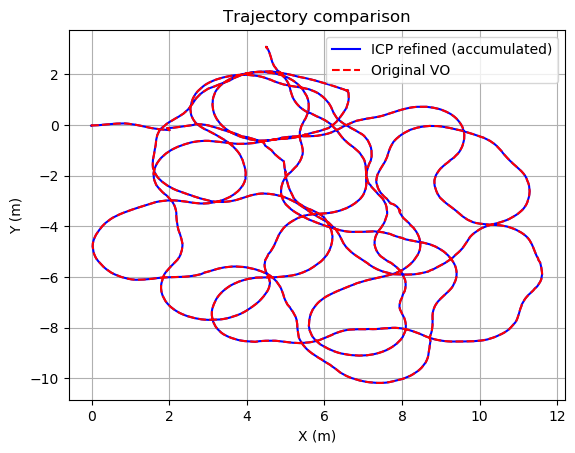

In [11]:

plt.figure()
refined_x = [T[0,3] for T in refined_poses]
refined_y = [T[1,3] for T in refined_poses]
refined_yaw = [np.arctan2(T[0,2], T[2,2]) for T in refined_poses]
original_x = [T[0,3] for T in vo_cam_pose[start_frame:end_frame]]
original_y = [T[1,3] for T in vo_cam_pose[start_frame:end_frame]]
original_yaw = [np.arctan2(T[0,2], T[2,2]) for T in vo_cam_pose[start_frame:end_frame]]
plt.plot(refined_x, refined_y, 'b-', label='ICP refined (accumulated)')
plt.plot(original_x, original_y, 'r--', label='Original VO')
plt.title("Trajectory comparison")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()


## OCTOMAP

In [12]:
import math
from typing import Dict, Tuple, Iterable, Optional
import numpy as np

# --------- 유틸: 확률 <-> 로그오즈 ----------
def logit(p: float) -> float:
    p = np.clip(p, 1e-6, 1.0 - 1e-6)
    return float(np.log(p / (1.0 - p)))

def inv_logit(l: float) -> float:
    return 1.0 / (1.0 + np.exp(-l))

# ============================================================
# IncrementalVoxelMapper: OctoMap-like sparse voxel mapping
# ============================================================
class IncrementalVoxelMapper:
    """
    Sparse 3D occupancy mapping with log-odds updates and 3D DDA raycasting.
    - resolution: voxel size (m)
    - l_occ / l_free: log-odds increments for hit / miss (free)
    - l_min / l_max: clamping of log-odds
    - occ_threshold: cells with log-odds > threshold are considered occupied
    """
    def __init__(
        self,
        resolution: float = 0.1,
        p_hit: float = 0.7,
        p_miss: float = 0.4,
        l_min: float = -5.0,
        l_max: float = 5.0,
        occ_threshold: float = 0.0,
    ):
        assert resolution > 0
        self.res = float(resolution)
        self.l_occ = logit(p_hit)
        self.l_free = -abs(logit(1.0 - p_miss))  # miss는 음수(감소)
        self.l_min = float(l_min)
        self.l_max = float(l_max)
        self.occ_threshold = float(occ_threshold)

        # sparse grid: key=(ix,iy,iz) -> log-odds value
        self.grid: Dict[Tuple[int, int, int], float] = {}

    # ---------- 좌표 변환 ----------
    def world_to_grid(self, xyz: np.ndarray) -> Tuple[int, int, int]:
        return tuple(np.floor(xyz / self.res).astype(int))  # (ix, iy, iz)

    def grid_to_world(self, idx: Tuple[int, int, int]) -> np.ndarray:
        # voxel center 좌표
        return (np.array(idx, dtype=float) + 0.5) * self.res

    # ---------- 조회 ----------
    def get_logodds(self, idx: Tuple[int, int, int]) -> float:
        return self.grid.get(idx, 0.0)

    def set_logodds(self, idx: Tuple[int, int, int], lval: float):
        if lval == 0.0:
            self.grid.pop(idx, None)
        else:
            self.grid[idx] = float(np.clip(lval, self.l_min, self.l_max))

    def add_logodds(self, idx: Tuple[int, int, int], delta: float):
        l = self.grid.get(idx, 0.0) + delta
        self.set_logodds(idx, l)

    def is_occupied(self, idx: Tuple[int, int, int]) -> bool:
        return self.get_logodds(idx) > self.occ_threshold

    # ---------- 핵심: 포즈 + 포인트클라우드 통합 ----------
    def update_from_scan(
        self,
        T_W_C: np.ndarray,
        points_C: np.ndarray,
        max_range: Optional[float] = None,
        downsample: int = 1,
        valid_mask: Optional[np.ndarray] = None,
        is_world_frame: bool = False,
    ):
        """
        T_W_C: (4,4) 카메라(또는 라이다) 센서 포즈 (world←camera)
        points_C: (N,3) 센서 좌표계의 포인트들
        max_range: 레이 최대 길이(m). None이면 무제한
        downsample: 1 이상 정수. >1이면 간단히 포인트 다운샘플
        valid_mask: 유효 포인트만 True인 마스크(옵션)
        """
        assert T_W_C.shape == (4, 4)
        assert points_C.ndim == 2 and points_C.shape[1] == 3

        # 샘플 수 줄이기
        if downsample > 1:
            points_C = points_C[::downsample]
            if valid_mask is not None:
                valid_mask = valid_mask[::downsample]

        # 유효 포인트 필터
        if valid_mask is not None:
            points_C = points_C[valid_mask]

        if is_world_frame:
            points_W = points_C
        else:
            # 동차변환으로 월드 좌표로 변환
            ones = np.ones((points_C.shape[0], 1), dtype=points_C.dtype)
            points_C_h = np.hstack([points_C, ones])
            points_W = (T_W_C @ points_C_h.T).T[:, :3]

        origin_W = T_W_C[:3, 3].copy()

        # 각 포인트에 대해 레이캐스팅 (빈공간 감소, 끝점 증가)
        for pW in points_W:
            ray_vec = pW - origin_W
            dist = float(np.linalg.norm(ray_vec))

            if dist < 1e-6:
                continue

            # 최대 거리 제한
            hit_point = pW
            hit_is_capped = False
            if max_range is not None and dist > max_range:
                hit_point = origin_W + ray_vec * (max_range / dist)
                hit_is_capped = True

            # 1) 원점→(히트포인트 - eps) 까지 free 업데이트
            self._raycast_free(origin_W, hit_point, max_range)

            # 2) 끝점 셀은 occupied 업데이트 (단, 최대거리 캡이면 히트가 아님)
            if not hit_is_capped:
                end_idx = self.world_to_grid(hit_point)
                self.add_logodds(end_idx, self.l_occ)

    # ---------- 3D DDA로 free 업데이트 ----------
    def _raycast_free(self, start_W: np.ndarray, end_W: np.ndarray, max_range: Optional[float] = None):
        """
        Amanatides & Woo (1987) 스타일의 3D DDA.
        end 셀은 포함하지 않고 free만 업데이트.
        """
        res = self.res

        # 시작/끝 인덱스
        start_idx = np.floor(start_W / res).astype(int)
        end_idx = np.floor(end_W / res).astype(int)

        ix, iy, iz = start_idx.tolist()
        ex, ey, ez = end_idx.tolist()

        # 방향
        ray = end_W - start_W
        if np.allclose(ray, 0):
            return
        dirx, diry, dirz = ray / np.linalg.norm(ray)

        step_x = 1 if dirx > 0 else -1
        step_y = 1 if diry > 0 else -1
        step_z = 1 if dirz > 0 else -1

        # 다음 voxel 경계까지의 t
        def int_bound(s, ds, i, step):
            # 현재 voxel 경계(좌/우)까지의 거리 비율 t
            if ds == 0:
                return math.inf
            # 현재 voxel의 최소/최대 경계 좌표
            voxel_border = (i + (1 if step > 0 else 0)) * res
            return (voxel_border - s) / ds

        tx = int_bound(start_W[0], dirx, ix, step_x)
        ty = int_bound(start_W[1], diry, iy, step_y)
        tz = int_bound(start_W[2], dirz, iz, step_z)

        # 축 방향으로 한 voxel 넘어갈 때 증가하는 t
        tdx = (res / abs(dirx)) if dirx != 0 else math.inf
        tdy = (res / abs(diry)) if diry != 0 else math.inf
        tdz = (res / abs(dirz)) if dirz != 0 else math.inf

        # 레이 길이
        max_t = np.linalg.norm(end_W - start_W) / np.linalg.norm(ray) # 1.0
        ray_length = np.linalg.norm(ray)

        # 시작 셀부터 진행 (끝 셀 제외)
        # start_idx와 end_idx가 같아도 end 제외 규칙으로 free 업데이트 없음
        while (ix, iy, iz) != (ex, ey, ez):
            # 현재 셀 free 업데이트
            # max range 근처면 감소량 조절
            # if max_range is None or ray_length < max_range:
            #     self.add_logodds((ix, iy, iz), self.l_free)
            # else:
            #     # max range 근처면 감소량 선형 감소
            #     tx_rel = (tx * np.linalg.norm(ray)) / ray_length  # 현재 위치까지의 거리 비율
            #     if tx_rel < max_range:
            #         free_scale = (max_range - tx_rel) / max_range
            #         self.add_logodds((ix, iy, iz), self.l_free * free_scale)
            #     else:
            #         break

            self.add_logodds((ix, iy, iz), self.l_free)

            # 다음 셀로 진행
            if tx < ty and tx < tz:
                if tx > max_t:  # end를 넘어섬
                    break
                ix += step_x
                tx += tdx
            elif ty < tz:
                if ty > max_t:
                    break
                iy += step_y
                ty += tdy
            else:
                if tz > max_t:
                    break
                iz += step_z
                tz += tdz

    # ---------- 결과 조회/Export ----------
    def get_occupied_voxels(self) -> Iterable[Tuple[Tuple[int,int,int], float]]:
        for k, l in self.grid.items():
            if l > self.occ_threshold:
                yield (k, l)

    def get_free_voxels(self) -> Iterable[Tuple[Tuple[int,int,int], float]]:
        for k, l in self.grid.items():
            if l <= self.occ_threshold and l < 0:
                yield (k, l)

    def get_occupied_points(self) -> np.ndarray:
        pts = []
        for (idx, _) in self.get_occupied_voxels():
            pts.append(self.grid_to_world(idx))
        return np.array(pts, dtype=float) if pts else np.zeros((0,3), dtype=float)

    def get_probability(self, idx: Tuple[int,int,int]) -> float:
        return float(inv_logit(self.get_logodds(idx)))

    def slice_xy(self, z: float, size: int = 200, center: Optional[np.ndarray] = None) -> np.ndarray:
        """
        간단한 시각화용 XY 슬라이스 (확률 맵 0~1).
        size: 출력 해상도 (size x size)
        center: [x,y] 월드 좌표를 중심으로 표시 (None이면 (0,0))
        """
        if center is None:
            center = np.zeros(2)
        half = size // 2
        out = np.full((size, size), 0.5, dtype=float)
        z_idx = int(np.floor(z / self.res))

        for iy in range(size):
            for ix in range(size):
                xw = (ix - half) * self.res + center[0]
                yw = (iy - half) * self.res + center[1]
                idx = (int(np.floor(xw / self.res)), int(np.floor(yw / self.res)), z_idx)
                l = self.get_logodds(idx)
                out[iy, ix] = inv_logit(l)
        return out

    def to_open3d_geometry(self):
        """
        (옵션) Open3D가 설치되어 있으면 점군으로 변환
        occupied만 회색 점으로 반환
        """
        try:
            import open3d as o3d
        except ImportError:
            return None

        pts = self.get_occupied_points()
        if pts.shape[0] == 0:
            return o3d.geometry.PointCloud()
        pcd = o3d.geometry.PointCloud(o3d.utility.Vector3dVector(pts))
        return pcd
    
    def update_from_world(
        self,
        T_W_C: np.ndarray,
        points_W: np.ndarray,
        max_range: Optional[float] = None,
        downsample: int = 1,
        valid_mask: Optional[np.ndarray] = None,
    ):
        """
        월드 좌표계 기준 포인트클라우드를 직접 업데이트.
        - T_W_C: (4,4) 카메라 포즈 (world←camera), 레이 원점을 얻기 위해 사용
        - points_W: (N,3) 월드 좌표계 포인트들
        """
        assert T_W_C.shape == (4, 4)
        assert points_W.ndim == 2 and points_W.shape[1] == 3

        # 다운샘플/마스크
        pts = points_W if downsample <= 1 else points_W[::downsample]
        if valid_mask is not None:
            pts = pts[valid_mask if downsample <= 1 else valid_mask[::downsample]]

        origin_W = T_W_C[:3, 3].copy()

        for pW in pts:
            ray_vec = pW - origin_W
            dist = float(np.linalg.norm(ray_vec))
            if dist < 1e-6:
                continue

            hit_point = pW
            hit_is_capped = False
            if max_range is not None and dist > max_range:
                hit_point = origin_W + ray_vec * (max_range / dist)
                hit_is_capped = True

            # 빈 공간 업데이트
            self._raycast_free(origin_W, hit_point)

            # 끝점(히트) 업데이트 (max_range로 잘린 경우 생략)
            if not hit_is_capped:
                end_idx = self.world_to_grid(hit_point)
                self.add_logodds(end_idx, self.l_occ)


In [13]:
mapper = IncrementalVoxelMapper(
    resolution=0.1,   # 10cm 보셀
    p_hit=0.7,        # 히트 시 증가 폭
    p_miss=0.4,       # 빈 공간 관측 시 감소 폭
    l_min=-5.0, l_max=5.0,
    occ_threshold=0.0 # 0보다 크면 occupied로 간주 (~확률 0.5 초과)
)

def make_T(R=np.eye(3), t=np.zeros(3)):
    T = np.eye(4)
    T[:3,:3] = R
    T[:3, 3] = t
    return T

# --- 예시: 시점 k의 카메라 포즈 (월드←카메라) ---
# 카메라가 (0,0,1.0)m 위치, 회전은 항등
# T_W_C_k = make_T(np.eye(3), np.array([0.0, 0.0, 1.0]))

# --- 예시: 그 시점의 포인트클라우드 (이미 월드 좌표계) ---
# 카메라 앞 쪽에 있는 벽/물체를 가정한 랜덤 포인트들 (z≈1.0에서 z방향 +x 전방)
# N = 8000
# x: 1.5~3.0m 앞, y: -1~1m, z: 0.2~1.8m 범위의 월드 좌표 포인트
# points_W_k = np.column_stack([
#     np.random.uniform(1.5, 3.0, size=N),
#     np.random.uniform(-1.0, 1.0, size=N),
#     np.random.uniform(0.2, 1.8, size=N),
# ])

# --- 업데이트: 월드 포인트 직접 사용 ---
# mapper.update_from_world(T_W_C_k, points_W_k, max_range=3.5, downsample=2)

# --- 다음 프레임 k+1: 카메라가 약간 이동/회전했고,
#     이전에 점유로 잘못 본 영역을 이번에 빈공간으로 많이 본다고 가정 ---
# 카메라를 x로 0.2m 이동, 약간의 yaw 회전
# yaw = np.deg2rad(5.0)
# Rz = np.array([
#     [np.cos(yaw), -np.sin(yaw), 0.0],
#     [np.sin(yaw),  np.cos(yaw), 0.0],
#     [0.0,          0.0,         1.0],
# ])
# T_W_C_k1 = make_T(Rz, np.array([0.2, 0.0, 1.0]))

# 이번에는 같은 공간을 스캔하되, 표면이 실제보다 뒤에 있다고 잘못 인식했던 포인트들이
# 빈공간으로 관측되도록 일부 포인트를 '조금 더 멀리' 이동시켜서 히트가 안 나게 구성
# (실제로는 센서가 끝점보다 짧은 max_range로 자르거나 레이가 빈 공간만 지나가게 되는 상황)
# points_W_k1 = points_W_k.copy()
# points_W_k1[:, 0] += 0.5  # x방향으로 0.5m 뒤쪽으로 밀어 히트가 줄고 free가 많아지게


for i in range(len(refined_poses)):
    T_W_C_k1 = refined_poses[i]
    points_W_k1 = np.asarray(pcl_list[i].points)
    # 업데이트
    mapper.update_from_scan(T_W_C_k1, points_W_k1, max_range=3.0, downsample=0, is_world_frame=True)

# --- 결과 확인: 점유 보셀 수/예시 좌표 ---
occupied_points_W = mapper.get_occupied_points()
print("Occupied voxels:", occupied_points_W.shape[0])
if occupied_points_W.shape[0] > 0:
    print("Sample occupied voxel center (first 5):\n", occupied_points_W[:5])


Occupied voxels: 13545
Sample occupied voxel center (first 5):
 [[1.95 1.05 0.25]
 [1.85 1.05 0.25]
 [1.05 1.05 0.15]
 [1.75 1.05 0.25]
 [1.05 1.15 0.15]]


In [18]:

# --- (옵션) Open3D 시각화 ---
mapper.occ_threshold = logit(0.8)  # 확률 ~이상을 점유로 간주
pcd = mapper.to_open3d_geometry()
if pcd is not None:
    import open3d as o3d
    pcd = pcd.remove_radius_outlier(nb_points=30, radius=0.3)[0]
    o3d.visualization.draw_geometries([pcd])

pcd_octomap = pcd


# --- (옵션) 2D 슬라이스 확인 (z=1.0 근처)
# prob_map = mapper.slice_xy(z=1.0, size=200, center=np.array([1.5, 0.0]))
# print("Slice prob map shape:", prob_map.shape)

#### target pose

In [87]:
target_pose_refined = []
for i in range(len(target_pose)):
    P_c_t = [-target_pose[i][1], -target_pose[i][2], target_pose[i][0]]  # 카메라 좌표계 (Z, -X, -Y)
    P_w_t = refined_poses[i] @ np.array([P_c_t[0], P_c_t[1], P_c_t[2], 1.0])
    target_pose_refined.append((P_w_t[0], P_w_t[1], P_w_t[2]))


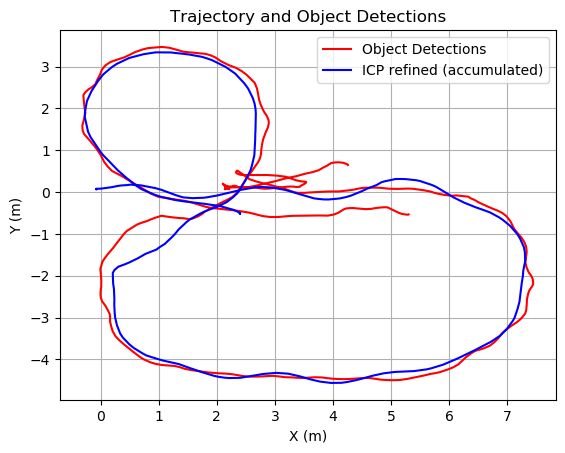

In [88]:
target_pose_x = [p[0] for p in target_pose_refined]
target_pose_y = [p[1] for p in target_pose_refined]

start = 0
end = len(target_pose_x)

plt.figure()
plt.plot(target_pose_x[start:end], target_pose_y[start:end], 'r-', label='Object Detections')
plt.plot(refined_x[start:end], refined_y[start:end], 'b-', label='ICP refined (accumulated)')
plt.title("Trajectory and Object Detections")
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.grid()
plt.legend()

## Record as rosbag


## Plotting


In [ ]:
# z cliping
# z_low = -0.5
# z_high = 0.5

# test_pcl = pcl_after_list[500]
# points = np.asarray(test_pcl.points)

# valid_indices = np.where((points[:,2] >= z_low) & (points[:,2] <= z_high))[0]
# clipped_pcl = test_pcl.select_by_index(valid_indices)

# o3d.visualization.draw_geometries([clipped_pcl])

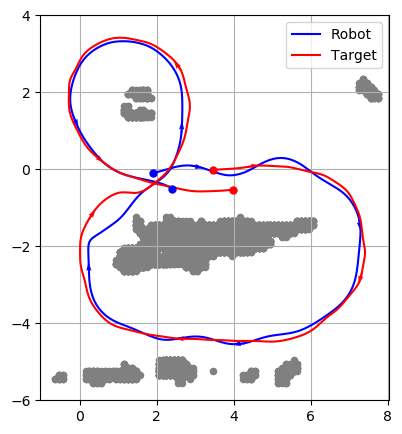

In [119]:


pcl_2d = np.array(pcd_octomap.points)

########## target, agent traj ###########
start = 110
end = len(refined_poses) - 20


refined_x = [T[0,3] for T in refined_poses[start:end]]
refined_y = [T[1,3] for T in refined_poses[start:end]]

target_pose_x = [p[0] for p in target_pose_refined[start:end]]
target_pose_y = [p[1] for p in target_pose_refined[start:end]]

# smoothing
from scipy.ndimage import gaussian_filter1d
refined_x = gaussian_filter1d(refined_x, sigma=2)
refined_y = gaussian_filter1d(refined_y, sigma=2)

target_pose_x = gaussian_filter1d(target_pose_x, sigma=2)
target_pose_y = gaussian_filter1d(target_pose_y, sigma=2)

########## rotate for better view
angle = np.deg2rad(-0)
cos_a = np.cos(angle)
sin_a = np.sin(angle)
refined_x_rot = cos_a * np.array(refined_x) - sin_a * np.array(refined_y)
refined_y_rot = sin_a * np.array(refined_x) + cos_a * np.array(refined_y)
refined_x = refined_x_rot
refined_y = refined_y_rot
target_pose_x_rot = cos_a * np.array(target_pose_x) - sin_a * np.array(target_pose_y)
target_pose_y_rot = sin_a * np.array(target_pose_x) + cos_a * np.array(target_pose_y)
target_pose_x = target_pose_x_rot
target_pose_y = target_pose_y_rot
pcl_2d_rot = np.zeros_like(pcl_2d)
pcl_2d_rot[:,0] = cos_a * pcl_2d[:,0] - sin_a * pcl_2d[:,1]
pcl_2d_rot[:,1] = sin_a * pcl_2d[:,0] + cos_a * pcl_2d[:,1]
pcl_2d_rot[:,2] = pcl_2d[:,2]
pcl_2d = pcl_2d_rot.copy()

############# FINAL PLOT #############

plt.figure(figsize=(4.5, 5))
plt.axis('equal')
plt.xlim(-1, 8)
plt.ylim(-6, 4)
plt.grid()

plt.plot(refined_x, refined_y, 'b-', label='Robot')
plt.plot(target_pose_x, target_pose_y, 'r-', markersize=2, label='Target')
# color with height
# z_min = np.min(pcl_2d[:,2])
# z_max = np.max(pcl_2d[:,2])
# color_map = plt.get_cmap('jet')
# colors = color_map((pcl_2d[:,2] - z_min) / (z_max - z_min))
# sc = plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=1, c=colors, alpha=0.5)
plt.scatter(pcl_2d[:,0], pcl_2d[:,1], s=20, c='gray', alpha=1)

# indicate start and end
plt.plot(refined_x[0], refined_y[0], 'bo', markersize=5)
plt.plot(refined_x[-1], refined_y[-1], 'bo', markersize=5)

plt.plot(target_pose_x[0], target_pose_y[0], 'ro', markersize=5)
plt.plot(target_pose_x[-1], target_pose_y[-1], 'ro', markersize=5)

# plot arrow for direction
arrow_interval = 50
for i in range(10, len(refined_x), arrow_interval):
    if i + 1 < len(refined_x):
        dir = np.array([refined_x[i+3]-refined_x[i], refined_y[i+3]-refined_y[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(refined_x[i], refined_y[i], dir[0], dir[1],
                    scale=8, scale_units='inches', width=0.005, color='b')
for i in range(10, len(target_pose_x), arrow_interval):
    if i + 1 < len(target_pose_x):
        dir = np.array([target_pose_x[i+3]-target_pose_x[i], target_pose_y[i+3]-target_pose_y[i]])
        dir = dir / np.linalg.norm(dir) * 1
        plt.quiver(target_pose_x[i], target_pose_y[i], dir[0], dir[1],
                     scale=8, scale_units='inches', width=0.005, color='r')

# plt.xlabel("X (m)")
# plt.ylabel("Y (m)")
plt.legend()


### save as rosbag

## icp with gtsam (TBD)

In [281]:
import gtsam
import gtsam.utils.plot as gtsam_plot
import matplotlib.pyplot as plt

In [282]:
def o3d_relative_icp_and_info(pcd_j, pcd_i, T_init, use_point_to_plane, max_corr_dist):
    """
    pcd_j를 pcd_i로 정합(즉, i 기준에서 j의 상대변환 추정).
    T_init: 초기값 (i->j 상대변환 추정치)
    return: T_ij (4x4), info6 (6x6)  # Open3D 좌표계 기준
    """
    if use_point_to_plane:
        est = o3d.pipelines.registration.TransformationEstimationPointToPlane()
    else:
        est = o3d.pipelines.registration.TransformationEstimationPointToPoint()

    reg = o3d.pipelines.registration.registration_icp(
        pcd_j, pcd_i,
        max_correspondence_distance=max_corr_dist,
        init=T_init,
        estimation_method=est
    )
    T_ij = reg.transformation

    info6 = o3d.pipelines.registration.get_information_matrix_from_point_clouds(
        pcd_j, pcd_i, max_corr_dist, T_ij
    )  # 6x6 정보행렬 (SE3)

    return T_ij, info6

def info6_to_info2(info6):
    """
    Open3D가 주는 6x6( x y z roll pitch yaw ) 정보행렬에서
    2D( x y yaw ) block만 추출 (인덱스 [0,1,5]).
    """
    idx = [0, 1, 5]
    info2 = info6[np.ix_(idx, idx)]
    return info2

In [283]:
fx=261.167
fy=261.167
cx=323.5188
cy=179.9977
width, height = 640, 360
intrinsic = o3d.camera.PinholeCameraIntrinsic(width, height, fx, fy, cx, cy)
pcl_list = []
depth_trunc = 5.0  # 사용할 depth 범위 (m)

for i in range(len(rgb_list)):
    rgb_o3d = o3d.geometry.Image(rgb_list[i].astype(np.uint8))
    depth_o3d = o3d.geometry.Image(depth_list[i].astype(np.float32))
    rgbd = o3d.geometry.RGBDImage.create_from_color_and_depth(
        rgb_o3d, depth_o3d, depth_scale = 1.0, depth_trunc=depth_trunc,
        convert_rgb_to_intensity=False
    )
    pcd = o3d.geometry.PointCloud.create_from_rgbd_image(rgbd, intrinsic)
    pcd = pcd.voxel_down_sample(0.05)
    pcd = pcd.remove_statistical_outlier(nb_neighbors=10,std_ratio=1.0)[0]
    pcd.estimate_normals(search_param=o3d.geometry.KDTreeSearchParamHybrid(radius=0.1, max_nn=30))
    pcl_list.append(pcd)
print(f"Loaded {len(pcl_list)} point clouds.")

Loaded 654 point clouds.


In [284]:

graph = gtsam.NonlinearFactorGraph()
initial = gtsam.Values()
Pose2 = gtsam.Pose2

# 0번 prior (아주 강하게 고정)
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([1e-6, 1e-6, 1e-6]))
x0, y0, yaw0 = poses2d[0]
graph.add(gtsam.PriorFactorPose2(0, Pose2(x0, y0, yaw0), prior_noise))
initial.insert(0, Pose2(x0, y0, yaw0))

robust_scale  = 1.0    # robust kernel scale (Cauchy/Huber 등)

# 1) VO 에지 추가 (연속 프레임)
for i in range(1, len(poses2d)):
    x1,y1,t1 = poses2d[i-1]
    x2,y2,t2 = poses2d[i]
    dx, dy, dth = x2-x1, y2-y1, (t2 - t1)
    rel = Pose2(dx, dy, dth)

    # 공분산 → 노이즈모델 (VO의 i번째 측정 공분산 사용)
    cov = covs2d[i]
    noise_vo = gtsam.noiseModel.Gaussian.Covariance(cov)

    # (선택) 로버스트 커널로 감싸도 됨
    # noise_vo = gtsam.noiseModel.Robust.Create(
    #     gtsam.noiseModel.mEstimator.Cauchy(robust_scale),
    #     gtsam.noiseModel.Gaussian.Covariance(cov)
    # )

    graph.add(gtsam.BetweenFactorPose2(i-1, i, rel, noise_vo))
    # 초기값은 VO 절대 pose 그대로
    initial.insert(i, Pose2(x2, y2, t2))



In [302]:

# ----------------------------
# 2) ICP 에지 추가 (keyframe들 사이)
#    - 선택적으로 근접한 이웃 KF에 대해서만 추가 (계산량 절약)
#    - 정보행렬은 Open3D 제공 util로 계산 → 2D block만 사용
# ----------------------------
keyframe_step = 5  # keyframe 간격

keyframes = list(range(0, len(poses2d), keyframe_step))
neighbor_gaps = [1, 10]  # k->k+1, k->k+2 정도만 연결 (loop 비슷한 효과)
for kk, k in enumerate(keyframes):
    Ti = pose2d_to_mat4(*poses2d[k])

    for gap in neighbor_gaps:
        if kk + gap >= len(keyframes):
            continue
        m = keyframes[kk + gap]

        Tj = pose2d_to_mat4(*poses2d[m])

        # 초기 상대추정: VO 기반 (i->j)
        T_ij_init = np.linalg.inv(Ti) @ Tj

        # ICP 정합 + 정보행렬
        time_diff = (vo_time[m] - vo_time[k]).to_sec()
        max_corr_dist = time_diff * 1.5  # 1.5 m
        T_ij_icp, info6 = o3d_relative_icp_and_info(pcl_list[m], pcl_list[k], T_ij_init, use_point_to_plane=True, max_corr_dist=max_corr_dist)
        info2 = info6_to_info2(info6)

        # 정보행렬이 나왔으니 GTSAM noise = Gaussian.Information(info2)
        # (로버스트 커널 권장)
        base_noise = gtsam.noiseModel.Gaussian.Information(info2)
        noise_icp = gtsam.noiseModel.Robust.Create(
            gtsam.noiseModel.mEstimator.Cauchy(robust_scale),
            base_noise
        )

        # ICP 상대변환을 2D로 투영해서 BetweenFactorPose2로 추가
        dx, dy, dth = mat4_to_pose2d(T_ij_icp)
        graph.add(gtsam.BetweenFactorPose2(k, m, gtsam.Pose2(dx, dy, dth), noise_icp))


params = gtsam.LevenbergMarquardtParams()
params.setVerbosityLM("ERROR")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial, params)
result = optimizer.optimize()


In [306]:
poses2d_opt = []
for i in range(len(poses2d)):
    p = result.atPose2(i)
    poses2d_opt.append((p.x(), p.y(), p.theta()))

WARNING - 2025-09-23 02:18:19,595 - legend - No handles with labels found to put in legend.


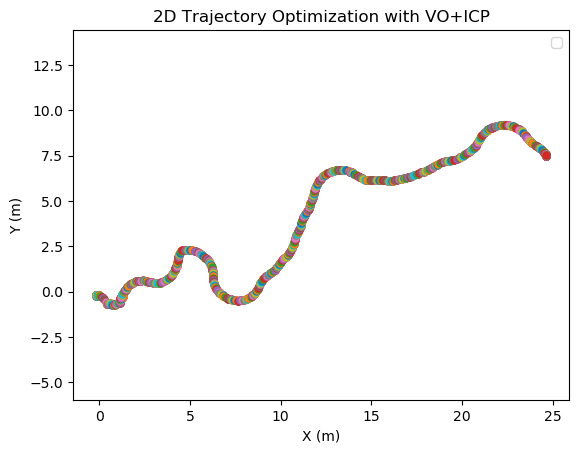

In [307]:
plt.figure()   
poses2d_array = np.array(poses2d)[:, :2].T

poses2d_opt_array = np.array(poses2d_opt)[:, :2].T

gtsam_plot.plot_point2(fignum=1, point=poses2d_array, linespec='r--')
gtsam_plot.plot_point2(fignum=1, point=poses2d_opt_array, linespec='.')
plt.xlabel("X (m)")
plt.ylabel("Y (m)")
plt.axis('equal')
plt.legend()
plt.title("2D Trajectory Optimization with VO+ICP")
plt.show()
import numpy as np  
import open3d as o3d
